# FGW–DFT Correlation Analysis (Three-Panel Figure)

This notebook reads **three CSV files** containing `fgw_distance` and `relaxed_energy`, computes **Pearson** and **Spearman** correlation coefficients for each dataset, and generates a **compact horizontal three-panel figure** in a journal-style layout:

- wide horizontal panels
- deep-blue semi-transparent scatter points
- black linear fit
- light-gray 95% confidence band
- visible top/right spines without top/right ticks
- outward bottom/left ticks
- plain-text correlation annotation: `r = ..., ρ = ...`
- vector output only (`.svg` and `.pdf`)

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import pearsonr, spearmanr, linregress, t

# -----------------------------
# Global plotting style
# -----------------------------
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 8.5,
    'axes.labelsize': 9,
    'axes.titlesize': 8.5,
    'axes.titleweight': 'semibold',
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.linewidth': 1.0,
    'xtick.major.width': 0.9,
    'ytick.major.width': 0.9,
    'xtick.major.size': 3.2,
    'ytick.major.size': 3.2,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
    'figure.dpi': 150,
    'savefig.dpi': 600,
})

POINT_COLOR = "#3F6C88"  # deep blue with transparency
CI_COLOR = '#d3d3d3'                     # light gray confidence band
LINE_COLOR = 'black'
AXES_COLOR = 'black'

In [87]:
# -----------------------------
# Input files and labels
# -----------------------------
# Replace these with your own CSV paths
csv_paths = [
    '../dft_results/KI_NaCl.csv',
    '../dft_results/GaP_GaAs.csv',
    '../dft_results/GaN_Al2O3.csv',
]

panel_titles = [
    'KI/NaCl',
    'GaP/GaAs',
    'GaN/Al$_2$O$_3$',
]

# Vector outputs only
output_pdf = 'fgw_dft_correlation_three_panel.pdf'

In [88]:
# -----------------------------
# Helper functions
# -----------------------------
def load_dataset(csv_path):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f'CSV file not found: {csv_path}')

    df = pd.read_csv(csv_path)
    required_columns = ['fgw_distance', 'relaxed_energy']
    missing = [c for c in required_columns if c not in df.columns]
    if missing:
        raise ValueError(f'{csv_path}: missing required columns: {missing}')

    data = df[required_columns].apply(pd.to_numeric, errors='coerce').dropna().copy()
    if len(data) < 2:
        raise ValueError(f'{csv_path}: need at least 2 valid data points.')

    return data


def linear_fit_with_ci(x, y, confidence=0.95, n_grid=200):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    fit = linregress(x, y)
    slope, intercept = fit.slope, fit.intercept

    x_grid = np.linspace(x.min(), x.max(), n_grid)
    y_fit = intercept + slope * x_grid

    n = len(x)
    x_mean = np.mean(x)
    sxx = np.sum((x - x_mean) ** 2)
    y_hat = intercept + slope * x
    residuals = y - y_hat
    s_err = np.sqrt(np.sum(residuals ** 2) / (n - 2))

    t_crit = t.ppf((1.0 + confidence) / 2.0, df=n - 2)
    se_mean = s_err * np.sqrt(1.0 / n + (x_grid - x_mean) ** 2 / sxx)
    ci = t_crit * se_mean

    return {
        'slope': slope,
        'intercept': intercept,
        'x_grid': x_grid,
        'y_fit': y_fit,
        'y_lower': y_fit - ci,
        'y_upper': y_fit + ci,
        'rvalue': fit.rvalue,
        'pvalue': fit.pvalue,
        'stderr': fit.stderr,
    }


def draw_panel(ax, data, title):
    x = data['fgw_distance'].to_numpy(dtype=float)
    y = data['relaxed_energy'].to_numpy(dtype=float)

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)
    fit = linear_fit_with_ci(x, y, confidence=0.95)

    ax.scatter(
        x, y,
        s=12,
        color=POINT_COLOR,
        edgecolors='none',
        zorder=3,
        alpha=0.6
    )

    ax.fill_between(
        fit['x_grid'], fit['y_lower'], fit['y_upper'],
        color=CI_COLOR,
        zorder=1,
    )

    ax.plot(
        fit['x_grid'], fit['y_fit'],
        color=LINE_COLOR,
        linewidth=1.0,
        zorder=4,
    )

    ax.set_title(title, pad=4.5)
    ax.set_xlabel('FGW distance')

    # show all spines, but only left/bottom ticks
    for side in ['top', 'right', 'bottom', 'left']:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)
        ax.spines[side].set_color(AXES_COLOR)

    ax.tick_params(
        axis='both',
        which='both',
        direction='out',
        top=False,
        right=False,
        labeltop=False,
        labelright=False,
        pad=4,
    )

    annotation = f'$r$ = {pearson_r:.3f}, $\\rho$ = {spearman_rho:.3f}'
    ax.text(
        0.04, 0.965, annotation,
        transform=ax.transAxes,
        va='top', ha='left',
        fontsize=8.2,
        zorder=5,
    )

    return {
        'n': len(data),
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_rho': spearman_rho,
        'spearman_p': spearman_p,
    }

In [89]:

# -----------------------------
# Load datasets and print summary
# -----------------------------
if not (len(csv_paths) == len(panel_titles) == len(panel_labels) == 3):
    raise ValueError('Please provide exactly three CSV paths, three panel titles, and three panel labels.')

all_data = [load_dataset(path) for path in csv_paths]

summary_rows = []
for path, title, data in zip(csv_paths, panel_titles, all_data):
    x = data['fgw_distance'].to_numpy(dtype=float)
    y = data['relaxed_energy'].to_numpy(dtype=float)
    pearson_r, pearson_p = pearsonr(x, y)
    spearman_rho, spearman_p = spearmanr(x, y)
    summary_rows.append({
        'dataset': title,
        'csv_path': str(path),
        'n_points': len(data),
        'pearson_r': pearson_r,
        'pearson_p': pearson_p,
        'spearman_rho': spearman_rho,
        'spearman_p': spearman_p,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,dataset,csv_path,n_points,pearson_r,pearson_p,spearman_rho,spearman_p
0,KI/NaCl,../dft_results/KI_NaCl.csv,24,0.125843,0.557925,0.363172,0.081104
1,GaP/GaAs,../dft_results/GaP_GaAs.csv,24,0.694681,0.000165,0.629335,0.000985
2,GaN/Al$_2$O$_3$,../dft_results/GaN_Al2O3.csv,24,0.575141,0.003280,0.569126,0.003703


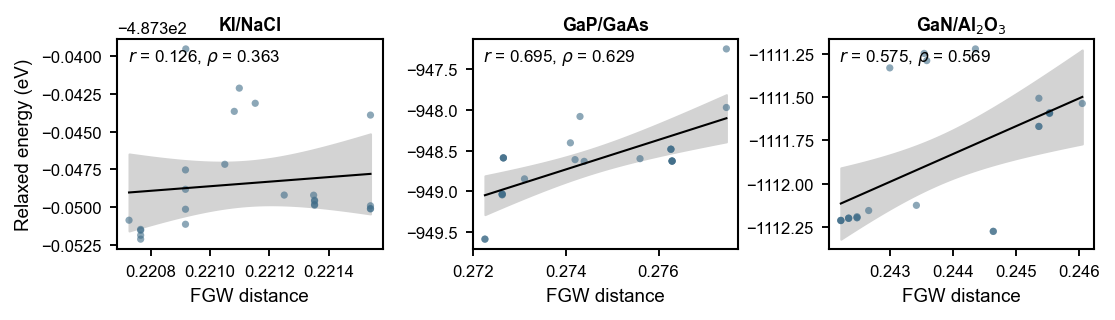

Saved: fgw_dft_correlation_three_panel.pdf


In [90]:
# -----------------------------
# Make the three-panel figure
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.25))
plt.subplots_adjust(left=0.09, right=0.995, bottom=0.22, top=0.84, wspace=0.34)

results = []
for ax, data, title in zip(axes, all_data, panel_titles):
    res = draw_panel(ax, data, title)
    results.append(res)

axes[0].set_ylabel('Relaxed energy (eV)')
axes[1].set_ylabel('')
axes[2].set_ylabel('')

plt.savefig(output_pdf, bbox_inches='tight')
plt.show()

print(f'Saved: {output_pdf}')